[*********************100%***********************]  1 of 1 completed
C:\Users\Asus Tuf Gaming\AppData\Local\Temp\ipykernel_17284\4248544843.py:14: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  S0 = float(data['Close'].iloc[-1])  # Harga sekarang (scalar)


Harga sekarang (S₀): 2590.00 PLN
Volatility (σ): 56.85%
Strike price (K): 2849.00 PLN


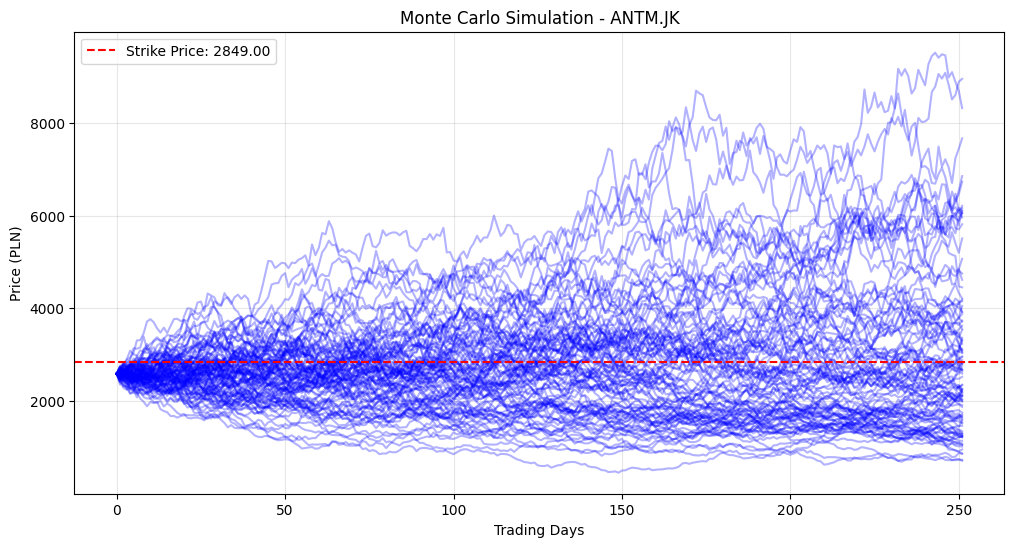


=== HASIL SIMULASI ===
Rata-rata harga akhir: 2734.35 PLN
Median harga akhir: 2342.45 PLN
Std dev harga akhir: 1684.74 PLN
Probabilitas harga > Strike: 36.70%


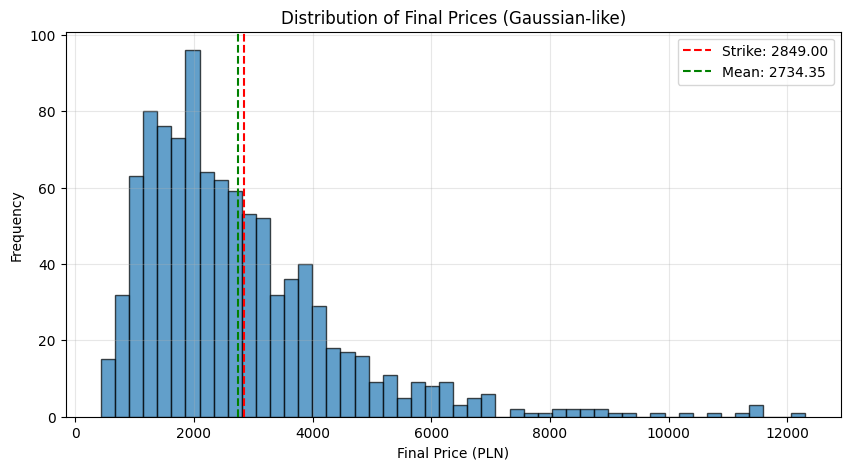

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

# === STEP 1: AMBIL DATA BBCA ===
ticker = "ANTM.JK"  # BBCA
data = yf.download(ticker, period="1y")

# Hitung daily returns
data['Returns'] = data['Close'].pct_change()
data = data.dropna()

# === STEP 2: HITUNG PARAMETER ===
S0 = float(data['Close'].iloc[-1])  # Harga sekarang (scalar)
sigma = data['Returns'].std() * np.sqrt(252)  # Annualized volatility
r = 0.05  # Risk-free rate (5% per tahun)
T = 1.0  # 1 tahun
K = S0 * 1.1  # Strike price 10% di atas harga sekarang

print(f"Harga sekarang (S₀): {S0:.2f} PLN")
print(f"Volatility (σ): {sigma:.2%}")
print(f"Strike price (K): {K:.2f} PLN")

# === STEP 3: MONTE CARLO SIMULATION ===
np.random.seed(42)
num_simulations = 1000
num_days = 252  # Trading days dalam 1 tahun

# Generate random paths
dt = T / num_days
paths = np.zeros((num_simulations, num_days))
paths[:, 0] = S0

for t in range(1, num_days):
    # Geometric Brownian Motion: dS = μS dt + σS dW
    drift = (r - 0.5 * sigma**2) * dt
    diffusion = sigma * np.random.normal(0, 1, num_simulations) * np.sqrt(dt)
    paths[:, t] = paths[:, t-1] * np.exp(drift + diffusion)

# === STEP 4: VISUALISASI ===
plt.figure(figsize=(12, 6))

# Plot 100 sample paths
for i in range(100):
    plt.plot(paths[i, :], alpha=0.3, color='blue')

plt.title(f'Monte Carlo Simulation - {ticker}')
plt.xlabel('Trading Days')
plt.ylabel('Price (PLN)')
plt.axhline(y=K, color='r', linestyle='--', label=f'Strike Price: {K:.2f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# === STEP 5: STATISTIK HASIL ===
final_prices = paths[:, -1]
print(f"\n=== HASIL SIMULASI ===")
print(f"Rata-rata harga akhir: {np.mean(final_prices):.2f} PLN")
print(f"Median harga akhir: {np.median(final_prices):.2f} PLN")
print(f"Std dev harga akhir: {np.std(final_prices):.2f} PLN")
print(f"Probabilitas harga > Strike: {np.mean(final_prices > K):.2%}")

# Histogram final prices
plt.figure(figsize=(10, 5))
plt.hist(final_prices, bins=50, edgecolor='black', alpha=0.7)
plt.title('Distribution of Final Prices (Gaussian-like)')
plt.xlabel('Final Price (PLN)')
plt.ylabel('Frequency')
plt.axvline(x=K, color='r', linestyle='--', label=f'Strike: {K:.2f}')
plt.axvline(x=np.mean(final_prices), color='g', linestyle='--', label=f'Mean: {np.mean(final_prices):.2f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [17]:
from scipy.stats import norm

def black_scholes(S, K, T, r, sigma, option_type='call'):
    """
    Black-Scholes formula untuk pricing European options
    
    S = Current stock price
    K = Strike price
    T = Time to expiration (in years)
    r = Risk-free rate
    sigma = Volatility
    """
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    if option_type == 'call':
        price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:  # put
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
    
    return price

# Hitung harga call option
call_price = black_scholes(S0, K, T, r, sigma, 'call')
put_price = black_scholes(S0, K, T, r, sigma, 'put')

print(f"\n=== BLACK-SCHOLES PRICING ===")
print(f"Call Option Price: {call_price:.2f} IDR")
print(f"Put Option Price: {put_price:.2f} IDR")
print(f"\nInterpretasi:")
print(f"Kalau lo mau beli Call Option {ticker} (strike {K:.2f}, exp 1 tahun),")
print(f"harga WAJARNYA adalah {call_price:.2f} IDR")
print(f"Kalau market nawarin lebih mahal -> OVERVALUED (jangan beli)")
print(f"Kalau market nawarin lebih murah -> UNDERVALUED (beli!)")

print(f"=== PARAMETER YANG DIPAKAI ===")
print(f"Current Price (S₀): {S0:.2f} IDR")
print(f"Strike Price (K): {K:.2f} IDR")
print(f"Time to Expiration (T): {T} years")
print(f"Risk-free Rate (r): {r:.2%}")
print(f"Volatility (σ): {sigma:.2%}")


=== BLACK-SCHOLES PRICING ===
Call Option Price: 534.78 IDR
Put Option Price: 654.84 IDR

Interpretasi:
Kalau lo mau beli Call Option ANTM.JK (strike 2849.00, exp 1 tahun),
harga WAJARNYA adalah 534.78 IDR
Kalau market nawarin lebih mahal -> OVERVALUED (jangan beli)
Kalau market nawarin lebih murah -> UNDERVALUED (beli!)
=== PARAMETER YANG DIPAKAI ===
Current Price (S₀): 2590.00 IDR
Strike Price (K): 2849.00 IDR
Time to Expiration (T): 1.0 years
Risk-free Rate (r): 5.00%
Volatility (σ): 56.85%
